# Spatialize Visualization Tools

<span style="color: purple;">**This notebook has been tested with `spatialize v1.1.1`**</span>

The `spatialize.viz` module provides a consistent set of visualization tools built on top of matplotlib. This notebook covers the three main components:

- **Color palettes** — built-in discrete and continuous palettes, plus all [Scientific Colour Maps](https://www.fabiocrameri.ch/colourmaps/) (SCM)
- **`PlotStyle`** — a lightweight theme manager that can be used as a context manager
- **Plotting helpers** — `plot_colormap_data`, `plot_nongriddata`, `plot_scatter`,
  `plot_histogram`, and `plot_colormap_array`

In [1]:
# imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('../')                       # access utils.py from examples/

from spatialize.viz import (
    PlotStyle,
    get_available_palettes,
    get_palette,
    get_palette_colormap,
    show_palettes,
    plot_colormap_data,
    plot_nongriddata,
    plot_scatter,
    plot_histogram,
)
from utils import SyntheticScenario
from spatialize.data import load_drill_holes_andes_2D


## 1. Color Palettes

### 1.1 Listing available palettes

`get_available_palettes()` returns every palette known to the module — the built-in spatialize palettes first, followed by all SCM colormaps.

In [ ]:
all_palettes = get_available_palettes()

builtin = all_palettes[:6]          # spatialize custom palettes
scm     = all_palettes[6:]          # Scientific Colour Maps

print(f"Built-in palettes ({len(builtin)}):")
print("  ", builtin)

print(f"\nSCM palettes ({len(scm)}):")
print("  ", scm)

Built-in palettes (6):
   ['alges', 'alges_muted', 'precision', 'precision_dark', 'precision_muted', 'crest_r']

SCM palettes (39):
   ['acton', 'bam', 'bamO', 'bamako', 'batlow', 'batlowK', 'batlowW', 'berlin', 'bilbao', 'broc', 'brocO', 'buda', 'bukavu', 'cork', 'corkO', 'davos', 'devon', 'fes', 'glasgow', 'grayC', 'hawaii', 'imola', 'lajolla', 'lapaz', 'lipari', 'lisbon', 'managua', 'navia', 'nuuk', 'oleron', 'oslo', 'roma', 'romaO', 'tofino', 'tokyo', 'turku', 'vanimo', 'vik', 'vikO']


### 1.2 Visualising the built-in palettes

`show_palettes()` renders every palette as a horizontal gradient bar, making it easy to compare them side by side.

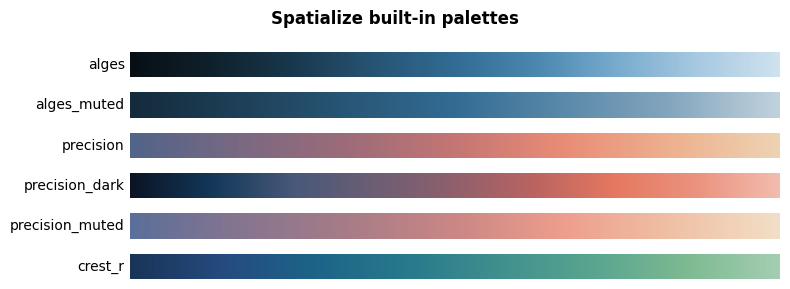

In [3]:
# Built-in palettes
show_palettes(names=builtin, title="Spatialize built-in palettes")

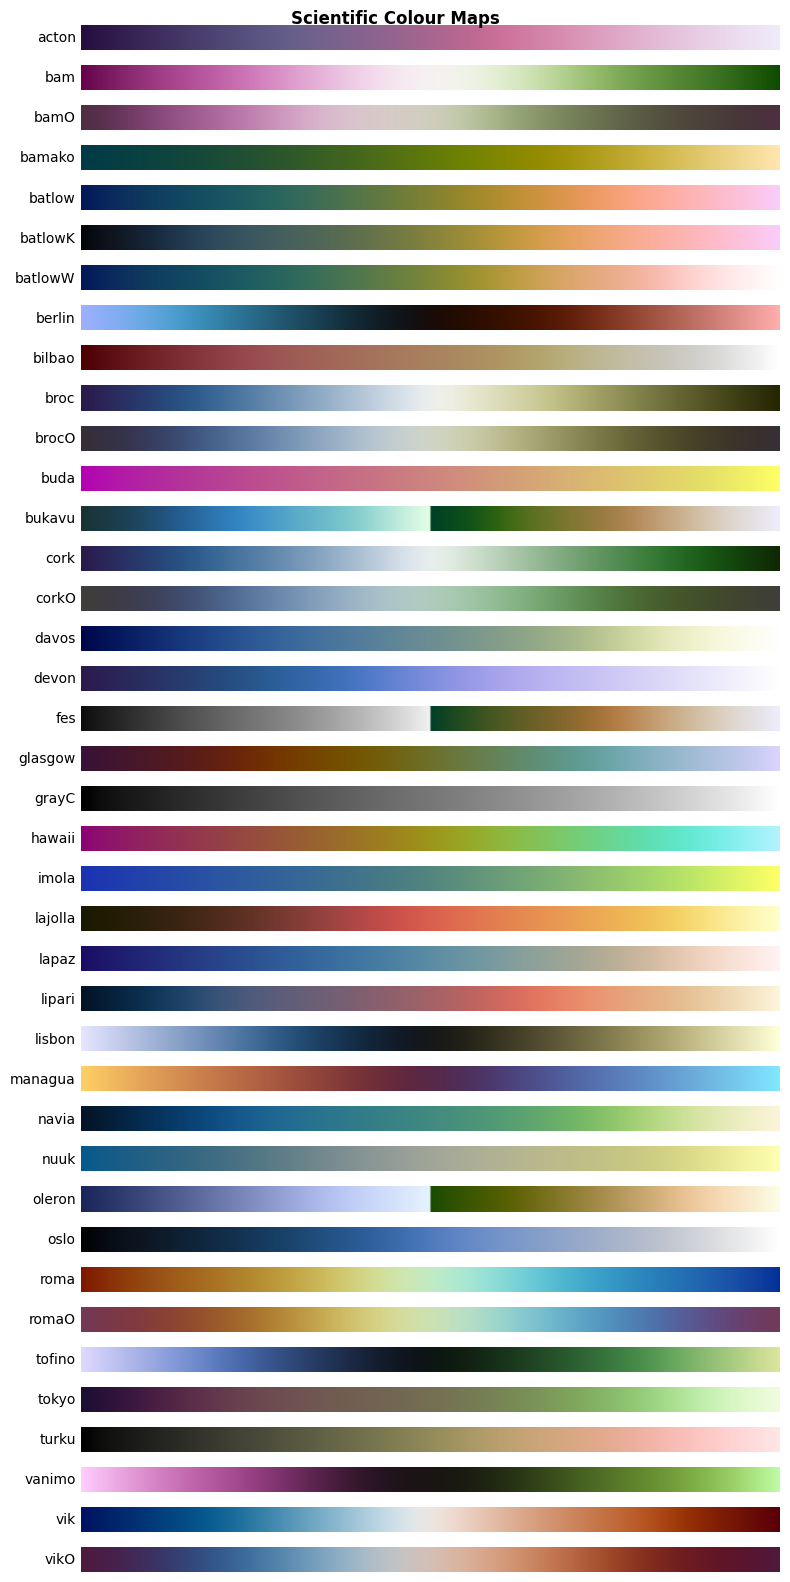

In [4]:
# SCM palettes
show_palettes(names=scm, title="Scientific Colour Maps")

### 1.3 Getting colors and colormaps programmatically

Use `get_palette()` to retrieve raw hex colors, or `get_palette_colormap()` to create a matplotlib `LinearSegmentedColormap`.

In [5]:
# Discrete hex colors
colors = get_palette('alges')
print("alges palette hex colors:")
for c in colors:
    print(f"  {c}")

alges palette hex colors:
  #070f15
  #0f212d
  #19384d
  #275474
  #326c94
  #4b87af
  #78abce
  #a7c9e1
  #cfe2ef


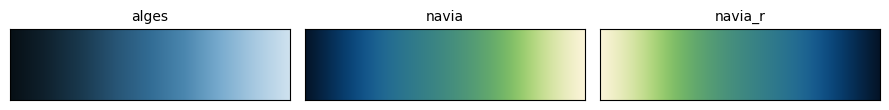

In [6]:
# Creating a custom colormap from a hex list, then reversing it
fig, axes = plt.subplots(1, 3, figsize=(9, 1.2))

for ax, (name, rev) in zip(axes, [('alges', False), ('navia', False), ('navia', True)]):
    cmap = get_palette_colormap(name, reverse=rev)
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect='auto', cmap=cmap)
    ax.set_xticks([]); ax.set_yticks([])
    label = f"{name}_r" if rev else name
    ax.set_title(label, fontsize=10)

plt.tight_layout()
plt.show()

## 2. PlotStyle

`PlotStyle` bundles three things: a matplotlib rcParams theme, a primary `color`, and two colormaps (`cmap` for data, `precision_cmap` for uncertainty). You can use it as a **context manager** (recommended) or manually call `reset_to_original()`.

### 2.1 Available themes

In [7]:
style = PlotStyle()
print("Available themes:", style.get_available_themes())

Available themes: ['darkgrid', 'whitegrid', 'dark', 'white', 'alges', 'alges_muted', 'minimal', 'publication']


Each theme exposes the attributes shown below; they can all be overridden at construction time.

| Attribute | Description |
|-----------|-------------|
| `style.color` | Primary line/marker color |
| `style.cmap` | Colormap for data fields |
| `style.precision_cmap` | Colormap for uncertainty/precision fields |


### 2.2 Theme gallery 

Because `PlotStyle` sets global matplotlib rcParams, the natural pattern is **one context block per figure**. The loop below is exactly how you would use it in practice — each `with` block creates its own fully-styled figure and restores defaults afterwards:

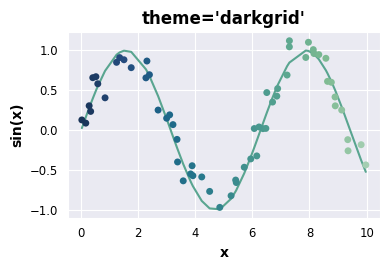

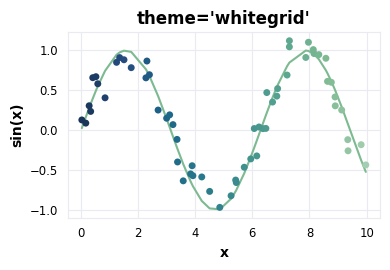

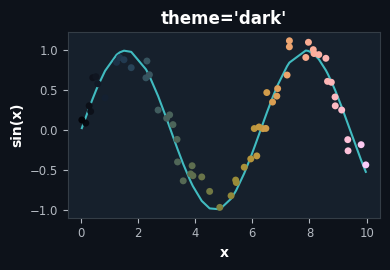

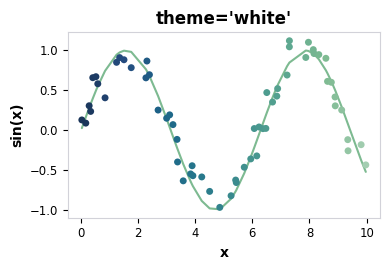

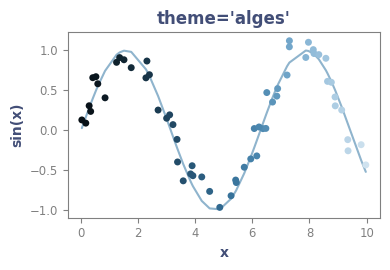

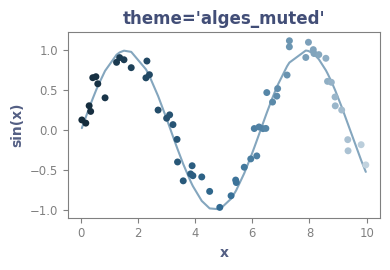

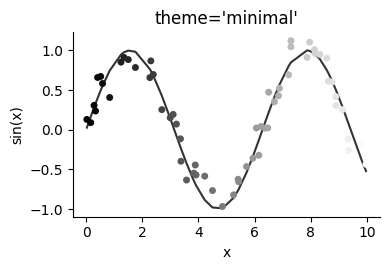

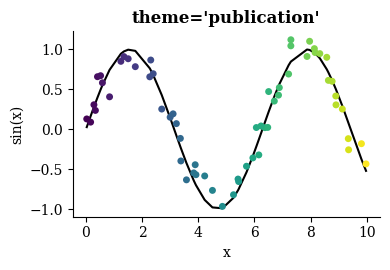

In [8]:
# Visualizing all eight built-in PlotStyle themes applied to the same scatter/line data
rng = np.random.default_rng(0)
x = rng.uniform(0, 10, 60)
y = np.sin(x) + rng.normal(0, 0.15, 60)
c = x                                       # color-mapped by x position

themes = ['darkgrid', 'whitegrid', 'dark', 'white',
          'alges', 'alges_muted', 'minimal', 'publication']

for theme in themes:
    with PlotStyle(theme=theme) as style:
        fig, ax = plt.subplots(figsize=(4, 2.8))
        ax.scatter(x, y, c=c, cmap=style.cmap, s=25, edgecolors='none', zorder=3)
        ax.plot(np.sort(x), np.sin(np.sort(x)), color=style.color, linewidth=1.5)
        ax.set_title(f"theme='{theme}'")
        ax.set_xlabel('x')
        ax.set_ylabel('sin(x)')
        plt.tight_layout()
        plt.show()

### 2.3 Overriding colors and colormaps

Every parameter can be overridden individually. Passing `cmap` as a string looks up built-in palettes and SCM names first, then falls back to matplotlib colormaps.

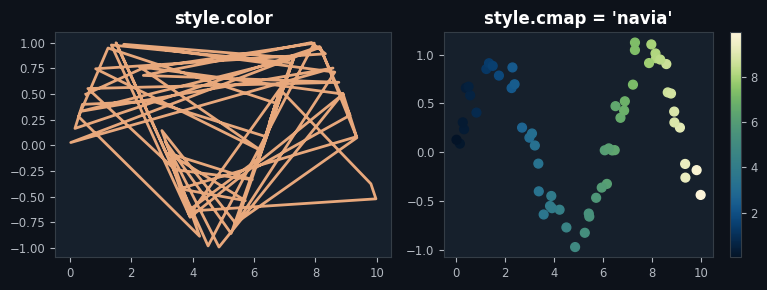

In [9]:
# Mixing a theme with custom colormap and primary color
with PlotStyle(theme='dark', cmap='navia', color='#e8a87c') as style:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    # Line plot using style.color
    axes[0].plot(x, np.sin(x), color=style.color, linewidth=2)
    axes[0].set_title("style.color")

    # Scatter using style.cmap
    sc = axes[1].scatter(x, y, c=c, cmap=style.cmap, s=40)
    plt.colorbar(sc, ax=axes[1])
    axes[1].set_title("style.cmap = 'navia'")

    plt.tight_layout()
    plt.show()

You can also pass a **list of hex colors** as `cmap` — it will be converted to a
`LinearSegmentedColormap` automatically:

In [10]:
# cmap-from-list
with PlotStyle(cmap=['#0f212d', '#4b87af', '#f7e0c4']) as style:
    print(type(style.cmap).__name__)     # LinearSegmentedColormap

LinearSegmentedColormap


### 2.4 Manual reset (alternative to context manager)

If you prefer not to use `with`, call `reset_to_original()` explicitly when done.

In [ ]:
# manual-reset
style = PlotStyle(theme='publication')
# ... your plotting code ...
style.reset_to_original()    # restore defaults

## 3. Plotting Functions

All plotting helpers accept an optional `ax` argument. When `ax=None` they create their own figure; when an axes is provided they draw into it, making it easy to compose multi-panel layouts.

### 3.1 `plot_histogram`

A styled histogram with auto-centering of tick labels on non-empty bins.

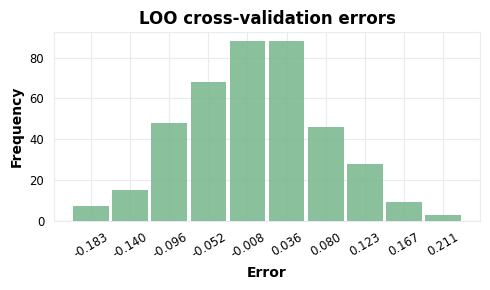

In [12]:
# Histogram of LOO cross-validation errors (synthetic)
rng = np.random.default_rng(42)
loo_errors = rng.normal(0, 0.08, 400)

with PlotStyle(theme='whitegrid') as style:
    fig, ax = plt.subplots(figsize=(5, 3))
    plot_histogram(loo_errors, ax=ax, color=style.color)
    ax.set_title("LOO cross-validation errors")
    plt.tight_layout()
    plt.show()

### 3.2 `plot_colormap_data` — regular grid data

This helper plots any 2-D grid using `imshow`. It accepts three input formats:

| Argument | Meaning |
|----------|---------|
| `griddata=True` | `data` has shape `(nx, ny)` — the ESI `griddata` format |
| `w` and `h` | flat `data` to be reshaped into `(h, w)` |
| `xi_locations` | flat `data` + scattered coordinate array `(n, 2)` |

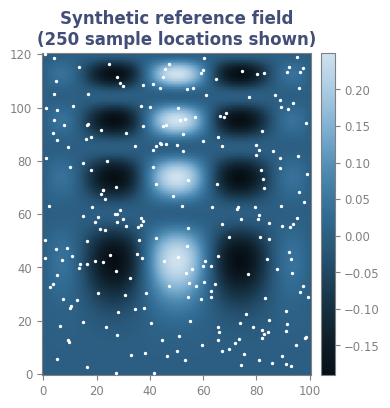

In [13]:
# Reference field from SyntheticScenario plotted with `plot_colormap_data`

scenario = SyntheticScenario(n_dims=2, extent=[0, 100, 0, 120], griddata=True)
points, values, xi, ref = scenario.simulate_scenario(n_samples=250, seed=7)

with PlotStyle(theme='alges') as style:
    fig, ax = plt.subplots(figsize=(4, 5))
    plot_colormap_data(ref, ax=ax, griddata=True, cmap=style.cmap)
    ax.scatter(points[:, 0], points[:, 1], s=2, color='white', zorder=3)
    ax.set_title("Synthetic reference field\n(250 sample locations shown)")
    plt.tight_layout()
    plt.show()

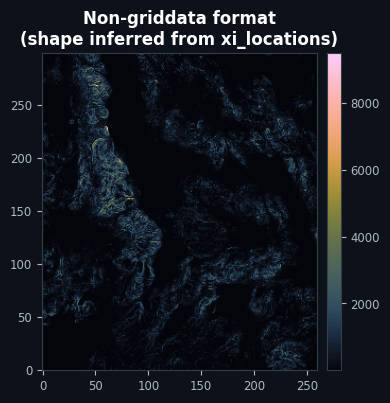

In [14]:
# `plot_colormap_data` with water-level reference dataset inferring shape from `xi_locations` (non-griddata format)
wlref = pd.read_csv('../../data/a_wlrefcleaned.csv')
xi_wl = wlref[['X', 'Y']].values
values_wl = wlref['value'].values

with PlotStyle(theme='dark') as style:
    fig, ax = plt.subplots(figsize=(4, 5))
    plot_colormap_data(values_wl, ax=ax, xi_locations=xi_wl, cmap=style.cmap)
    ax.set_title("Non-griddata format\n(shape inferred from xi_locations)")
    plt.tight_layout()
    plt.show()

### 3.3 `plot_nongriddata` — irregular spatial data

`plot_nongriddata` is designed for data on irregular or non-rectangular grids (e.g., lake bathymetry, watershed models). It uses xarray to arrange scattered points into a plottable array and fills gaps with `NaN`.

> **Note**: `xarray` is not automatically installed with spatialize, so you must manually install it in your environment if you want to use the `plot_nongriddata` function.

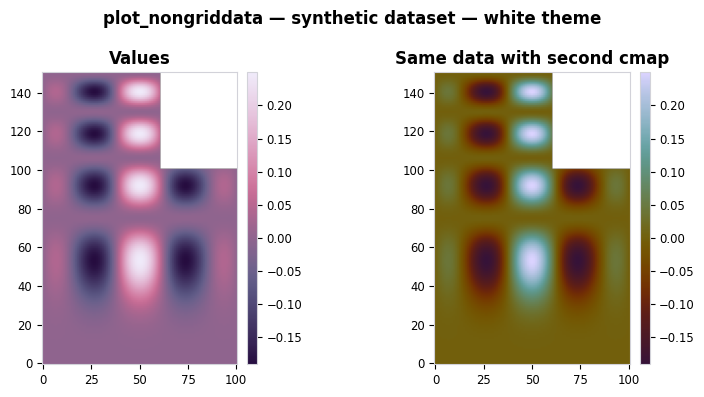

In [15]:
# Using `plot_nongriddata` to plot a non-rectangular domain

scenario = SyntheticScenario(n_dims=2, extent=[0, 100, 0, 150], griddata=False)
_, _, xi, reference_values = scenario.simulate_scenario(seed=42)

# Create incomplete grid
mask = (xi[:,0]<=60) | (xi[:,1]<=100)
xi_2 = xi[mask]
ref_2 = reference_values[mask]

with PlotStyle(theme='white', cmap='acton', precision_cmap='glasgow') as style:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    plot_nongriddata(ref_2, xi_locations=xi_2, ax=axes[0],
                     cmap=style.cmap)
    axes[0].set_title("Values")

    plot_nongriddata(ref_2, xi_locations=xi_2, ax=axes[1],
                     cmap=style.precision_cmap)
    axes[1].set_title("Same data with second cmap")

    plt.suptitle("plot_nongriddata — synthetic dataset — white theme",
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

### 3.4 `plot_scatter` — georeferenced scatter plots

`plot_scatter` wraps a styled scatter call and handles aspect ratio, extent, and an optional colorbar.

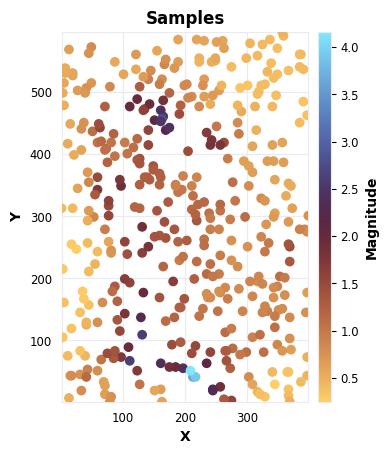

In [16]:
# Sample locations from the drill holes dataset coloured by value
samples, _, _, _ = load_drill_holes_andes_2D()

points = samples[['x', 'y']].values
values = samples[['cu']].values[:, 0]

plot_scatter(points, values, theme='whitegrid', cmap='managua', title='Samples')
plt.show()

### 3.5 Composing multiple helpers in one figure

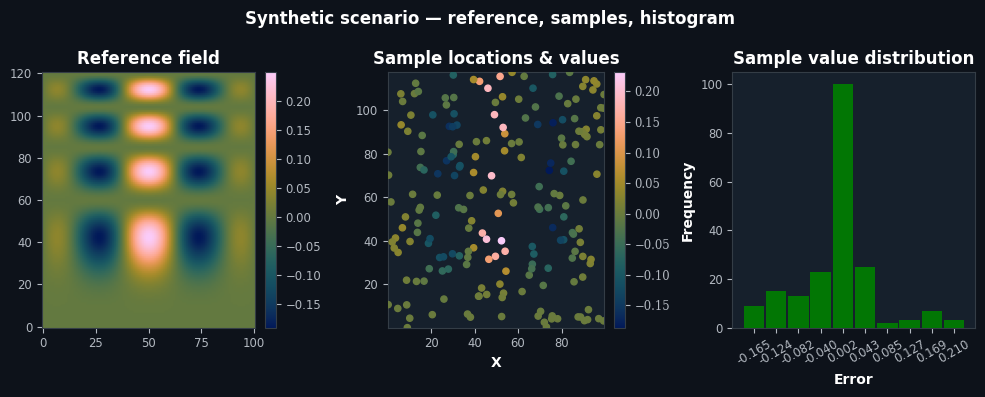

In [17]:
# Multi-panel figure combining PlotStyle, plot_colormap_data, and plot_histogram
scenario = SyntheticScenario(n_dims=2, extent=[0, 100, 0, 120], griddata=False)
points, values, xi, ref = scenario.simulate_scenario(n_samples=200, seed=21)

with PlotStyle(theme='dark', cmap='batlow', color='green') as style:
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    # Panel 1 — reference field
    plot_colormap_data(ref, ax=axes[0], griddata=False, xi_locations=xi, cmap=style.cmap)
    axes[0].set_title("Reference field")

    # Panel 2 — scatter of sample values
    plot_scatter(points, values, ax=axes[1], cmap=style.cmap, s=20, title="Sample locations & values", cbar_label="")
    
    # Panel 3 — histogram of sample values
    plot_histogram(values, ax=axes[2], color=style.color)
    axes[2].set_title("Sample value distribution")

    plt.suptitle("Synthetic scenario — reference, samples, histogram",
                 fontweight='bold')
plt.tight_layout()
plt.show()

## 4. PlotStyle with ESI Results

A typical workflow: run ESI, then use `PlotStyle` to plot the estimation and precision maps with a matching colormap pair. In fact, this is what the `quick_plot()` method of ESI results does from behind.

In [18]:
# esi run
from spatialize.gs.esi import esi_griddata

scenario = SyntheticScenario(n_dims=2, extent=[0, 100, 0, 120], griddata=True)
points, values, xi, ref = scenario.simulate_scenario(n_samples=300, seed=42)

result = esi_griddata(
    points, values, xi,
    local_interpolator='idw',
    p_process='mondrian',
    n_partitions=300,
    alpha=0.9,
    exponent=2.0,
)

estimation = result.estimation()
precision  = result.precision()

finished 100% of 300 iterations ... 

done (elapsed time:  3s)


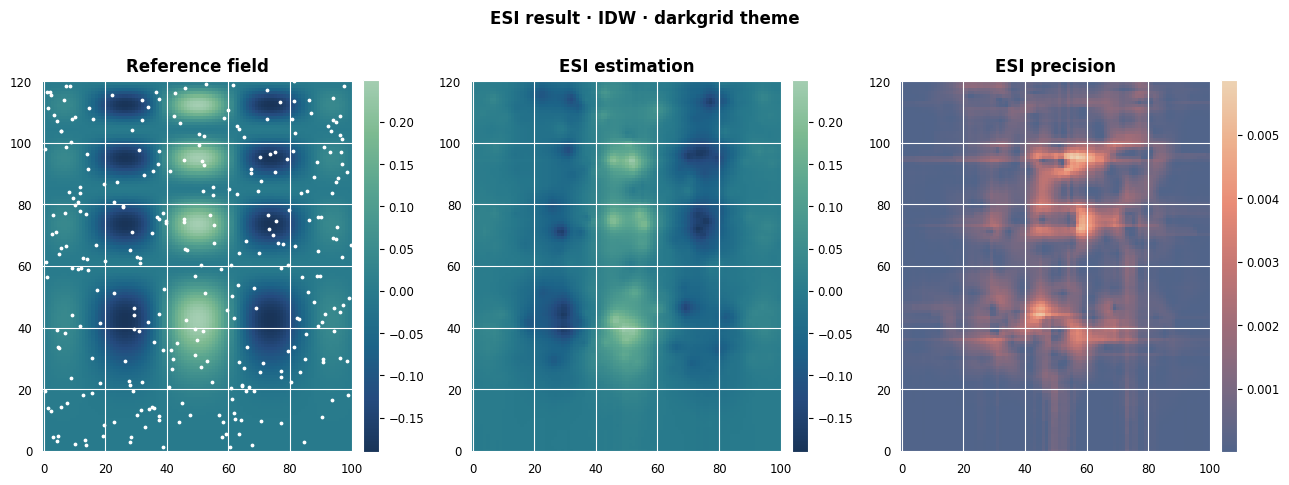

In [19]:
# ESI estimation and precision maps using matching PlotStyle colormaps"
with PlotStyle(theme='darkgrid') as style:
    fig, axes = plt.subplots(1, 3, figsize=(13, 5))

    # Reference
    plot_colormap_data(ref, ax=axes[0], griddata=True, cmap=style.cmap)
    axes[0].scatter(points[:, 0], points[:, 1], s=3, color='white', zorder=3)
    axes[0].set_title("Reference field")

    # Estimation — uses style.cmap (data colormap)
    plot_colormap_data(estimation, ax=axes[1], griddata=True, cmap=style.cmap, vmin=ref.min(), vmax=ref.max())
    axes[1].set_title("ESI estimation")

    # Precision — uses style.precision_cmap (uncertainty colormap)
    plot_colormap_data(precision, ax=axes[2], griddata=True,
                       cmap=style.precision_cmap)
    axes[2].set_title("ESI precision")

    plt.suptitle("ESI result · IDW · darkgrid theme", fontweight='bold')
plt.tight_layout()
plt.show()

### 4.1 Switching themes for presentation contexts

The same result plotted with different themes — no code changes other than the theme name:

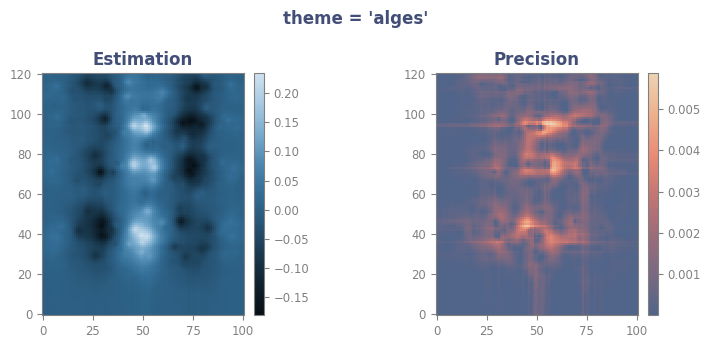

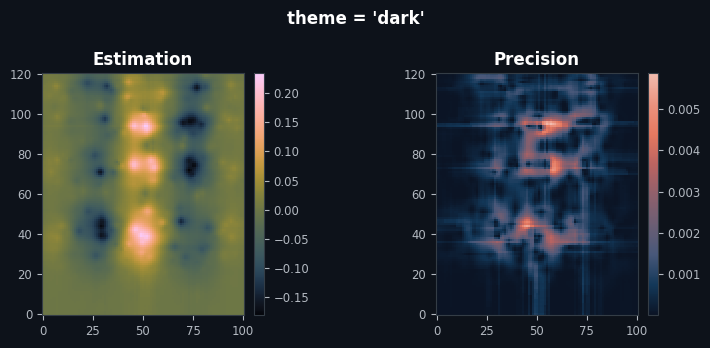

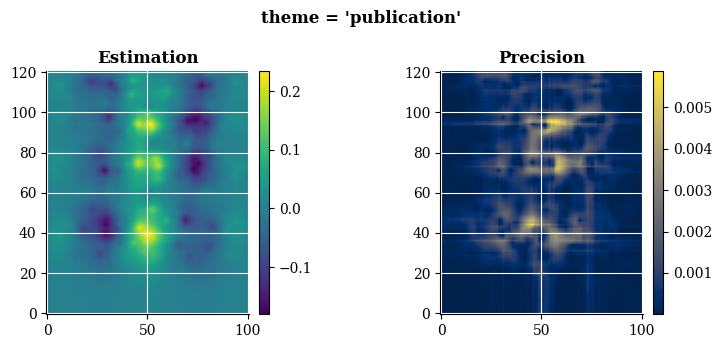

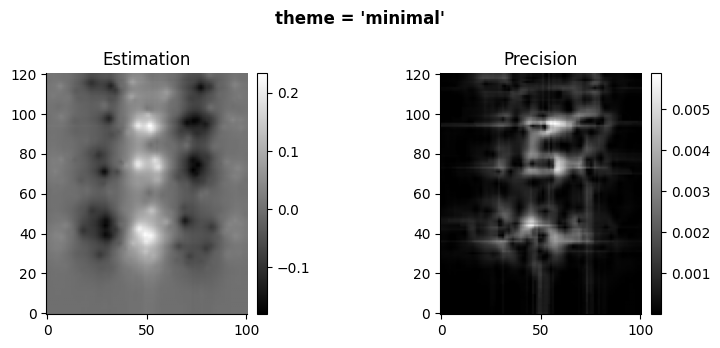

In [20]:
# The same ESI maps under 'dark', 'publication', and 'minimal' themes"
for theme in ['alges', 'dark', 'publication', 'minimal']:
    with PlotStyle(theme=theme) as style:
        fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

        plot_colormap_data(estimation, ax=axes[0], griddata=True, cmap=style.cmap)
        axes[0].set_title("Estimation")

        plot_colormap_data(precision, ax=axes[1], griddata=True,
                           cmap=style.precision_cmap)
        axes[1].set_title("Precision")

        plt.suptitle(f"theme = '{theme}'", fontweight='bold')
        plt.tight_layout()
        plt.show()

### 4.2 Using `quick_plot` (built into ESIResult)

`ESIResult.quick_plot()` accepts the same theme and cmap arguments and internally uses `PlotStyle`:

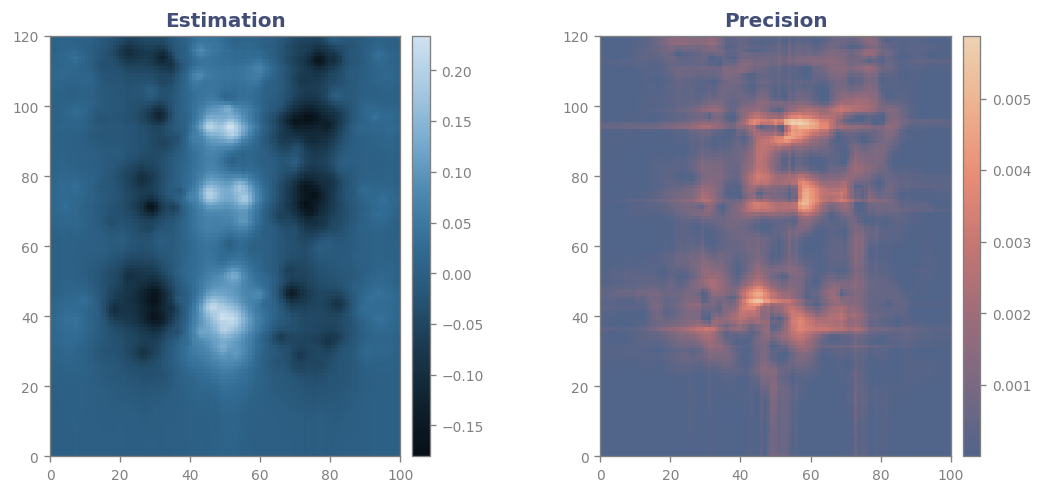

In [21]:
# quick plot
result.quick_plot(theme='alges')
plt.show()